# Handling Correlated Bosonic Baths with `pyttn.oqs`

### Contents

1. [Importing the Library](#importing-the-library)

2. [Correlated Bosonic Baths](#correlated-bosonic-baths)

    - [Bath Correlation Functions](#bath-correlation-functions)

3. [Discretise Baths](#discrete-baths)

4. [Sum-of-Exponential Baths](#sum-of-exponential-baths)

### Importing the Library

The first step of any pyTTN calculation is to import the Library.  For Open Quantum system calculations we will also want to import the `pyTTN.oqs` submodule as it provides several useful tools for easily setting up these calculations.


In [1]:
import os
os.environ['OMP_NUM_THREADS']='1'

import numpy as np
import matplotlib.pyplot as plt 
%matplotlib inline

import pyttn
from pyttn import oqs

/home/lachlan/pyttn/.venv/lib/python3.12/site-packages/numpy/_core/getlimits.py:548: UserWarning: Signature b'\x00\xd0\xcc\xcc\xcc\xcc\xcc\xcc\xfb\xbf\x00\x00\x00\x00\x00\x00' for <class 'numpy.longdouble'> does not match any known type: falling back to type probe function.
This warnings indicates broken support for the dtype!
  machar = _get_machar(dtype)


### Correlated Bosonic Baths

Now that we have imported the library we can begin setting up the OQS system information.  Here we will consider a more challenging case of a correlated Gaussian bosonic bath, in which the bath spectral density takes a matrix form that allows for cross correlation between bath modes associated with different system operators, with a thermal Gaussian Initial configuration.  In such a case, the influence of the bath on the system dynamics is entirely encoded in the bath Spectral function matrix

- At zero temperature, $\boldsymbol{S}(\omega) = \boldsymbol{J}(\omega) \quad \forall \, \omega > 0$

- At finite temperature, $\boldsymbol{S}(\omega) = \frac{1}{2} \boldsymbol{J}(\omega) \left( 1 + \frac{1}{\text{tanh}(\frac{\beta \omega}{2})} \right)$

where $\boldsymbol{J}(\omega)$ is the bath spectral density matrix, and encodes all information about the bath frequencies and coupling constants. In this example, we will consider a spectral density of the form:

$$
\boldsymbol{J}(\omega; r) = \frac{\pi}{2}\alpha \omega e^{-|\omega/\omega_c|} \begin{pmatrix} 1 & \cos(\frac{\omega r}{\nu}) \\ \cos(\frac{\omega r}{\nu}) & 1 \end{pmatrix}
$$.

which arises when considering two system degrees of freedom embedded in a one-dimensional phonon field.   Here, $\alpha$ is the Kondo parameter, $\omega_c$ is the cutoff frequency, $\nu$ is the speed of sound in the bath, and $r$ is the distance between the two bath sites.  We start by defining the bath spectral density function as a `pyttn.oqs.CorrelatedSpectralDensity` object:  

In [15]:
#set up the bath spectral density
alpha = 1.25
wc = 5
r = 1
nu = 1

# Exponential cutoff spectral density
J = oqs.CorrelatedSpectralDensity(2)
def Jaa(w):
    return np.abs(np.pi/2*alpha*w*np.exp(-np.abs(w/wc)))

def Jab(w):
    return Jaa(w)*np.cos(w*r/nu)

J[0,0] = Jaa
J[0,1] = Jab
J[1,0] = Jab
J[1,1] = Jaa


Within pyTTN, the `pyttn.oqs.CorrelatedBosonicBath` class has been provided for handling the spectral function of bosonic baths at both zero and finite temperature, and importantly wraps many of the core operations we would want to perform on such an object, e.g
    - Computing the corresponding bath correlation function
    - Evaluating a discrete bath that efficiently represents the influence of the bath on the system dynamics
    - Performing a sum-of-exponentials fit of the bath correlation function for use with pseudomode/HEOM methods.

We may construct a zero temperature bath using:

In [16]:
#build the bosonic bath with temperature T=0
bath_zero_T = oqs.bosonic_bath(J, beta=None)

Alternatively, we can create a finite temperature bath object by setting the inverse temperature $\beta=1/T$ as follows:

In [17]:
#build the bosonic bath with temperature T=1
T=2
bath_finite_T = oqs.bosonic_bath(J, beta=1/T)

#### Bath Spectral Functions

We can now readily compute the bath spectral functions using these `pyttn.oqs.CorrelatedBosonicBath` objects giving:

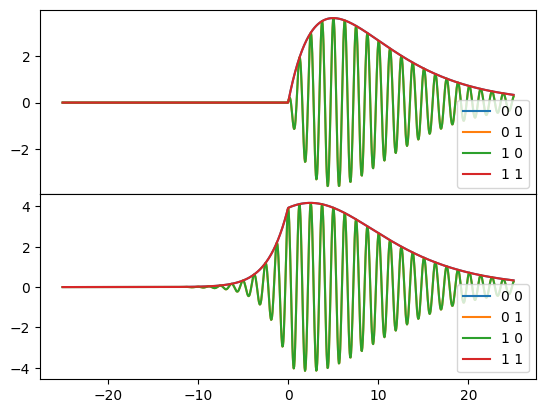

In [ ]:
w = np.linspace(-5*wc, 5*wc, 1000)

fig, ax = plt.subplots(nrows=2, ncols=1, sharex = True)
plt.subplots_adjust(hspace=0, wspace=0)

Sw0 = bath_zero_T.Sw(w)
for i in range(2):
    for j in range(2):
        ax[0].plot(w, np.real(Sw0[i, j]), label=r""+str(i)+" " + str(j))

Sw1 = bath_finite_T.Sw(w)

for i in range(2):
    for j in range(2):
        ax[1].plot(w, np.real(Sw1[i, j]), label=r""+str(i)+" " + str(j))

ax[0].legend()
ax[1].legend()

plt.show()

Additionally we support the evaluation of some scalar valued Spectral Function that is used when handling correlated bath fitting.  This supports several string values ("trace", "sum") that compute the scalar value from the matrix valued function, as well as arbitrary callable valued expressions.

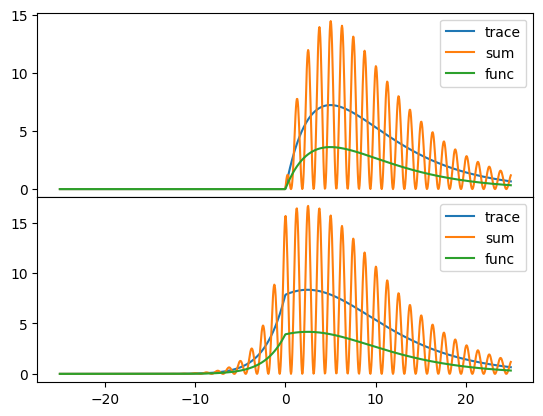

In [ ]:
fig, ax = plt.subplots(nrows=2, ncols=1, sharex = True)
plt.subplots_adjust(hspace=0, wspace=0)

sSw0a = bath_zero_T.scalarSw(w, scalar_func="trace")
sSw0b = bath_zero_T.scalarSw(w, scalar_func="sum")
sSw0c = bath_zero_T.scalarSw(w, scalar_func=Jaa)
ax[0].plot(w, np.real(sSw0a), label=r"trace")
ax[0].plot(w, np.real(sSw0b), label=r"sum")
ax[0].plot(w, np.real(sSw0c), label=r"func")

sSw1a = bath_finite_T.scalarSw(w, scalar_func="trace")
sSw1b = bath_finite_T.scalarSw(w, scalar_func="sum")
sSw1c = bath_finite_T.scalarSw(w, scalar_func=Jaa)
ax[1].plot(w, np.real(sSw1a), label=r"trace")
ax[1].plot(w, np.real(sSw1b), label=r"sum")
ax[1].plot(w, np.real(sSw1c), label=r"func")

ax[0].legend()
ax[1].legend()

plt.show()

#### Bath Correlation Functions

We can now readily compute the bath correlation functions using these `pyttn.oqs.CorrelatedBosonicBath` objects giving:

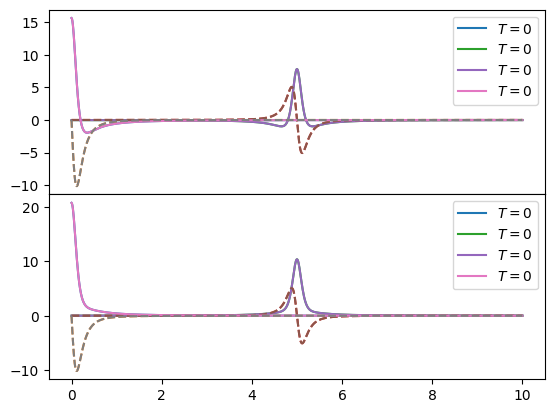

In [ ]:
t = np.linspace(0, 10, 1000)

fig, ax = plt.subplots(nrows=2, ncols=1, sharex = True)
plt.subplots_adjust(hspace=0, wspace=0)

Ct0 = bath_zero_T.Ct(t)
for i in range(2):
    for j in range(2):
        ax[0].plot(t, np.real(Ct0[i, j]), label=r"$T=0$")
        ax[0].plot(t, np.imag(Ct0[i, j]), '--')

Ct1 = bath_finite_T.Ct(t)

for i in range(2):
    for j in range(2):
        ax[1].plot(t, np.real(Ct1[i, j]), label=r"$T=0$")
        ax[1].plot(t, np.imag(Ct1[i, j]), '--')

ax[0].legend()
ax[1].legend()

plt.show()

As with the bath spectral function, we provide support for scalar valued correlation functions to be evaluated for help with certain bath fitting algorithms.

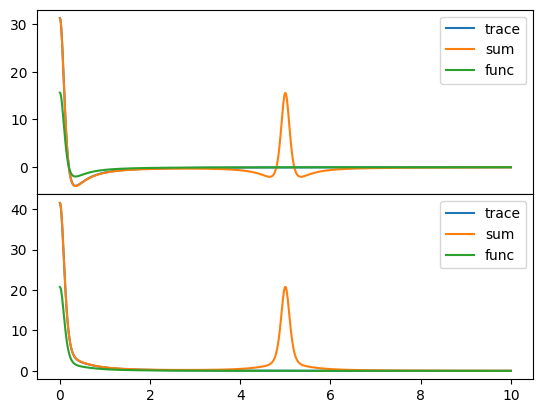

In [ ]:
fig, ax = plt.subplots(nrows=2, ncols=1, sharex = True)
plt.subplots_adjust(hspace=0, wspace=0)

sCt0a = bath_zero_T.scalarCt(t, scalar_func="trace")
sCt0b = bath_zero_T.scalarCt(t, scalar_func="sum")
sCt0c = bath_zero_T.scalarCt(t, scalar_func=Jaa)
ax[0].plot(t, np.real(sCt0a), label=r"trace")
ax[0].plot(t, np.real(sCt0b), label=r"sum")
ax[0].plot(t, np.real(sCt0c), label=r"func")

sCt1a = bath_finite_T.scalarCt(t, scalar_func="trace")
sCt1b = bath_finite_T.scalarCt(t, scalar_func="sum")
sCt1c = bath_finite_T.scalarCt(t, scalar_func=Jaa)
ax[1].plot(t, np.real(sCt1a), label=r"trace")
ax[1].plot(t, np.real(sCt1b), label=r"sum")
ax[1].plot(t, np.real(sCt1c), label=r"func")

ax[0].legend()
ax[1].legend()

plt.show()

The `pyttn.oqs.CorrelatedBosonicBath` object also contains several functions for constructing alternative representations of the bath needed for unitary dynamics, and pseudomode/HEOM dynamics simulations.  



### Discrete Baths

For unitary dynamics, we need to obtain a set of discrete bath frequencies and coupling constants defining a closed system bath that approximates the influence of the full open quantum system bath.  Within pyTTN, several methods have been provided for doing so, for details see the `pyttn.oqs.bath_fitting.bath_discretisation.py`.  When working with finite temperature baths, pyTTN will make use of the thermofields doubles approach to map the finite temperature problem onto the zero temperature dynamics of an effective temperature dependent Hamiltonian.  Here, we will demonstrate the use of the orthonormal polynomial based discretisation scheme (`pyttn.oqs.OrthopolDiscretisation`):

In [ ]:
Nb = 256
Nw = 10    
#discretise the zero temperature bath
g0,w0 = bath_zero_T.discretise(oqs.OrthopolDiscretisation(Nb, bath_zero_T.find_wmin(Nw*wc), Nw*wc), scalar_func="trace")

#discretise the finite temperature bath
g1,w1 = bath_finite_T.discretise(oqs.OrthopolDiscretisation(Nb, bath_finite_T.find_wmin(Nw*wc), Nw*wc), scalar_func="trace")

Here we have discretised the two baths, obtaining coupling constants $g$ and frequencies $\omega$ for each bath, using a total of $N_b=256$ bath frequencies, and have included frequencies up to $10 \omega_c$ when performing the discretisation process.  While these frequencies and coupling constants fully define the discrete bath, there are a few steps needed in order to actually use these within a simulation, namely:
    - Setting up system information objects
    - Truncating the Hilbert space dimension of each of the bosonic modes
    - Construction the system-bath coupling Hamiltonian
    - Setting up the Tree Structure to use for the simulation

 To help simplify this process, pyTTN includes the `pyttn.oqs.DiscreteBosonicBath` class that provides a set of function to significantly simplify each of these processes.  These steps will be explored in more detail below.  Here we will just set up a discrete bath object and use it to plot the discrete bath correlation function.

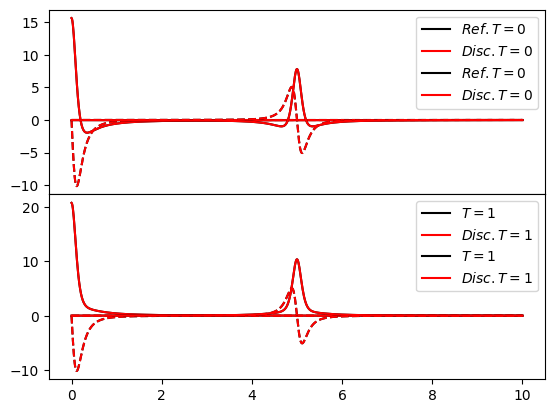

In [ ]:
disc_bath_zero_T = oqs.discrete_bosonic_bath(g0, w0)
disc_bath_finite_T = oqs.discrete_bosonic_bath(g1, w1)

Ctd0 = disc_bath_zero_T.Ct(t)
Ctd1 = disc_bath_finite_T.Ct(t)

fig, ax = plt.subplots(nrows=2, ncols=1, sharex = True)
plt.subplots_adjust(hspace=0, wspace=0)

#plot the bath correlation functions
Ct0 = bath_zero_T.Ct(t)
for i in range(2):
    ax[0].plot(t, np.real(Ct0[i, 0, :]), 'k', label=r"$Ref. T=0$")
    ax[0].plot(t, np.imag(Ct0[i, 0, :]), 'k--')
    ax[0].plot(t, np.real(Ctd0[i, 0, :]), 'r', label=r"$Disc. T=0$")
    ax[0].plot(t, np.imag(Ctd0[i, 0, :]), 'r--')

Ct1 = bath_finite_T.Ct(t)
for i in range(2):
    ax[1].plot(t, np.real(Ct1[i, 0, :]), 'k', label=r"$T=1$")
    ax[1].plot(t, np.imag(Ct1[i, 0, :]), 'k--')
    ax[1].plot(t, np.real(Ctd1[i, 0, :]), 'r', label=r"$Disc. T=1$")
    ax[1].plot(t, np.imag(Ctd1[i, 0, :]), 'r--')

ax[0].legend()
ax[1].legend()

plt.show()

Here we observe excellent agreement of the bath correlation functions over the time period considered.

### Sum-of-Exponential Baths

For non-unitary dynamics methods (e.g. pseudomode and HEOM), an alternative representation of the bath is employed, namely a sum-of-exponential decomposition of the bath correlation function.  Within pyTTN, several methods have been provided for doing so, for details see the `pyttn.oqs.bath_fitting.expfit.py` for more details. Here, we will demonstrate the use of the ESPRIT method (`pyttn.oqs.ESPRITDecomposition`) for doing so:

In [20]:
#specify the time step information used in the ESPRIT fitting
dt = 0.05
tmax = 15
nstep = int(tmax/dt)+1    

#specify the number of terms in the sum-of-exponential fit
K=10

#fit the zero and finite temperature baths
dk0, zk0 = bath_zero_T.expfit(oqs.ESPRITDecomposition(K=K, tmax=nstep*dt, Nt = nstep), scalar_func="sum")
dk1, zk1 = bath_finite_T.expfit(oqs.ESPRITDecomposition(K=K, tmax=nstep*dt, Nt = nstep), scalar_func="sum")

Here we have performed the sum-of-exponential fit for the two baths, obtaining coefficient constants $dk$ and decay rates $zk$ for each bath, using a total of $K=6$ terms in the decomposition.  As in the unitary case, there are still a few steps needed inorder to use these coefficient in a simulation.

 To help simplify this process, pyTTN includes the `pyttn.oqs.ExpFitBosonicBath` class that provides a set of function to significantly simplify each of the process of setting up dynamics simulations.  These steps will be explored in more detail below.  Here we will just set up a ExpFit bath object and use it to plot the discrete bath correlation function.

[[[0.23411698-4.09988918e-01j 0.20918479-4.87061405e-01j]
  [0.20918479-4.87061405e-01j 0.23411698-4.09988918e-01j]]

 [[0.23411698+4.09988918e-01j 0.20918479+4.87061405e-01j]
  [0.20918479+4.87061405e-01j 0.23411698+4.09988918e-01j]]

 [[0.26301366+4.03719402e-02j 0.14686952-4.86764791e-01j]
  [0.14686952-4.86764791e-01j 0.26301366+4.03719402e-02j]]

 [[0.26301366-4.03719402e-02j 0.14686952+4.86764791e-01j]
  [0.14686952+4.86764791e-01j 0.26301366-4.03719402e-02j]]

 [[1.21447454-7.71836599e-01j 1.95522068+2.78988561e-01j]
  [1.95522068+2.78988561e-01j 1.21447454-7.71836599e-01j]]

 [[1.21447454+7.71836599e-01j 1.95522068-2.78988561e-01j]
  [1.95522068-2.78988561e-01j 1.21447454+7.71836599e-01j]]

 [[0.46818644+8.00450855e-02j 0.73813922-7.94336135e-01j]
  [0.73813922-7.94336135e-01j 0.46818644+8.00450855e-02j]]

 [[0.46818644-8.00450855e-02j 0.73813922+7.94336135e-01j]
  [0.73813922+7.94336135e-01j 0.46818644-8.00450855e-02j]]

 [[1.95614556-2.22614145e-01j 0.92547324-4.45930375e+00j

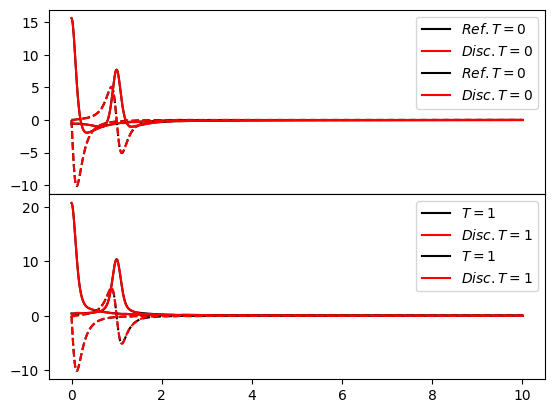

In [21]:
expfit_bath_zero_T = oqs.ExpFitCorrelatedBosonicBath(dk0, zk0)
expfit_bath_finite_T = oqs.ExpFitCorrelatedBosonicBath(dk1, zk1)

t = np.linspace(0, 10, 1000)

Ctd0 = expfit_bath_zero_T.Ct(t)
Ctd1 = expfit_bath_finite_T.Ct(t)

fig, ax = plt.subplots(nrows=2, ncols=1, sharex = True)
plt.subplots_adjust(hspace=0, wspace=0)

#plot the bath correlation functions
Ct0 = bath_zero_T.Ct(t)
for i in range(2):
    ax[0].plot(t, np.real(Ct0[i, 0, :]), 'k', label=r"$Ref. T=0$")
    ax[0].plot(t, np.imag(Ct0[i, 0, :]), 'k--')
    ax[0].plot(t, np.real(Ctd0[i, 0, :]), 'r', label=r"$Disc. T=0$")
    ax[0].plot(t, np.imag(Ctd0[i, 0, :]), 'r--')

Ct1 = bath_finite_T.Ct(t)
for i in range(2):
    ax[1].plot(t, np.real(Ct1[i, 0, :]), 'k', label=r"$T=1$")
    ax[1].plot(t, np.imag(Ct1[i, 0, :]), 'k--')
    ax[1].plot(t, np.real(Ctd1[i, 0, :]), 'r', label=r"$Disc. T=1$")
    ax[1].plot(t, np.imag(Ctd1[i, 0, :]), 'r--')

ax[0].legend()
ax[1].legend()

plt.show()

Here we observe considerably more efficient reproduction of the bath correlation function, which highlights one of the key advantages of using the non-unitary approaches over unitary approaches for OQS dynamics, namely the typically considerably more compact representation of the influence of the bath on the system for continuous bath spectral densities.